### Helpers

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==============================================================================
#  CONFIGURATION: DATA MAPPING
# ==============================================================================
# Define the column names here. 
# The script will use the first column name found in the CSVs.
# ==============================================================================

COLUMN_MAPPING = {
    # System Columns
    'time':       ['time'],
    'modus':      ['modus_val', 'modus'],

    # Inputs (Blue)
    'n_fan':      ['VD_n2'],                                  # Will be * 60
    'T_in':       ['TempKK'],
    'rh_in':      ['KK_rlFeuchteKK', 'rlFeuchteKK'],
    'm_ref':      ['MSS_rMassenstrom'],                       # Will be / 1000
    'p_ref_in':   ['VD_p_out'],
    'h_ref_in':   ['VD_h_in_korr', 'VD_isenthalp_h_in'],

    # Outputs (Red)
    'h_ref_out':  ['VD_h_out'],
    'dp':         ['Delta_P_VD'],
    
    # Special Handling for Frost Mass
    'mass_raw':   ['WAAGEN_Waage1_Masse_smooth', 'WAAGEN_Waage2_Masse']
}

# ==============================================================================
#  HELPER FUNCTIONS
# ==============================================================================

def get_data_col(df_main, df_kk, key_name):
    """
    Searches for the column defined in COLUMN_MAPPING in df_main, then df_kk.
    Returns the values if found, else None.
    """
    possible_names = COLUMN_MAPPING.get(key_name, [])
    
    for col in possible_names:
        if col in df_main.columns:
            return df_main[col]
        if col in df_kk.columns:
            return df_kk[col]
    return None

# ==============================================================================
#  MAIN PLOTTING FUNCTION
# ==============================================================================

def plot_experiments_simple(experiment_ids, path_exp, save_fig=False, group_name=None):
    """
    Simplified Dashboard: Visualization of N Experiments.
    """
    
    # 0. COLORS
    BLUE_GRADIENT = ['#89CFF0', '#4682B4', '#0047AB', '#000080', '#04043A']
    RED_GRADIENT  = ['#FFB3B3', '#FF8080', '#FF4D4D', '#E60000', '#8B0000']
    
    if len(experiment_ids) > 5:
        raise ValueError("Maximum 5 experiments allowed.")

    # 1. LOAD DATA
    experiments = []
    max_time = 0.0

    print(f"--- Processing {len(experiment_ids)} Experiments ---")

    for exp_id in experiment_ids:
        entry = {'id': exp_id, 'avail': False, 'time': None, 'data': {}}
        try:
            f_data = os.path.join(path_exp, f"{exp_id}_data.csv")
            f_kk = os.path.join(path_exp, f"{exp_id}_data_KK.csv")

            if os.path.exists(f_data) and os.path.exists(f_kk):
                # Load CSVs
                df = pd.read_csv(f_data, sep=';', decimal='.', on_bad_lines='skip', low_memory=False)
                df_kk = pd.read_csv(f_kk, sep=';', decimal='.', low_memory=False)

                # --- Filtering by Modus ---
                # We identify the valid indices based on the Modus column
                modus_series = get_data_col(df, df_kk, 'modus')
                
                if modus_series is not None:
                    mask = modus_series == 1
                    # Intersect indices to ensure we stay in bounds for both files
                    valid = df.index[mask].intersection(df_kk.index)
                    df = df.loc[valid]
                    df_kk = df_kk.loc[valid]

                if not df.empty:
                    # --- Time Normalization ---
                    t_raw = get_data_col(df, df_kk, 'time')
                    if t_raw is not None:
                        t_exp = (t_raw - t_raw.iloc[0]).values / 60.0
                        entry['time'] = t_exp
                        max_time = max(max_time, t_exp[-1] if len(t_exp) > 0 else 0)
                    else:
                        raise ValueError("Time column not found")

                    # --- Extract Data & Apply Calculations ---
                    d = {}
                    
                    # 1. Inputs
                    # Fan Speed
                    val_n = get_data_col(df, df_kk, 'n_fan')
                    d['n_fan'] = val_n.values * 60.0 if val_n is not None else np.zeros(len(df))
                    
                    # Temperatures & Humidity
                    val_T = get_data_col(df, df_kk, 'T_in')
                    d['T_in'] = val_T.values if val_T is not None else np.zeros(len(df))
                    
                    val_rh = get_data_col(df, df_kk, 'rh_in')
                    d['rh_in'] = val_rh.values if val_rh is not None else np.zeros(len(df))

                    # Reference Mass Flow
                    val_m = get_data_col(df, df_kk, 'm_ref')
                    d['m_ref'] = val_m.values / 1000.0 if val_m is not None else np.zeros(len(df))

                    # Pressures & Enthalpy
                    val_p_in = get_data_col(df, df_kk, 'p_ref_in')
                    d['p_ref_in'] = val_p_in.values if val_p_in is not None else np.zeros(len(df))

                    val_h_in = get_data_col(df, df_kk, 'h_ref_in')
                    d['h_ref_in'] = val_h_in.values if val_h_in is not None else np.zeros(len(df))

                    # 2. Outputs
                    val_h_out = get_data_col(df, df_kk, 'h_ref_out')
                    d['h_ref_out'] = val_h_out.values if val_h_out is not None else np.zeros(len(df))

                    val_dp = get_data_col(df, df_kk, 'dp')
                    d['dp'] = val_dp.values if val_dp is not None else np.zeros(len(df))
                    
                    # 3. Calculated Outputs
                    # Heat Flow Q
                    q_kw = d['m_ref'] * (d['h_ref_out'] - d['h_ref_in'])
                    d['Q'] = q_kw * 1000.0
                    
                    # Frost Mass (Calculated from Raw Mass)
                    val_mass_raw = get_data_col(df, df_kk, 'mass_raw')
                    if val_mass_raw is not None:
                        m_raw = val_mass_raw.values
                        d['m_frost'] = (m_raw - np.min(m_raw)) * 1000.0
                    else:
                        d['m_frost'] = np.zeros(len(df))

                    entry['data'] = d
                    entry['avail'] = True
        except Exception as e:
            print(f"Error loading {exp_id}: {e}")
        
        experiments.append(entry)

    # 2. PLOTTING (IDENTICAL TO ORIGINAL)
    fig = plt.figure(figsize=(24, 13))
    
    title_text = f"Dashboard: {group_name}" if group_name else f"Dashboard: {len(experiment_ids)} Experiments"
    fig.suptitle(title_text, fontsize=20, fontweight='bold', y=0.96)

    # Grids: Top (Inputs), Bottom (Outputs)
    gs_top = gridspec.GridSpec(2, 3, figure=fig, top=0.90, bottom=0.45, hspace=0.35, wspace=0.20)
    gs_bot = gridspec.GridSpec(1, 4, figure=fig, top=0.38, bottom=0.05, hspace=0.0, wspace=0.20)

    # Input Map (Blue)
    inputs = [
        (0, 0, 'n_fan', 'Fan Speed [rpm]'), (0, 1, 'T_in', 'Air Inlet Temp [°C]'), (0, 2, 'rh_in', 'Air Inlet RH [%]'),
        (1, 0, 'm_ref', 'Ref. Mass Flow [kg/s]'), (1, 1, 'h_ref_in', 'Ref. In Enthalpy [kJ/kg]'), (1, 2, 'p_ref_in', 'Evap. In Pressure [bar]')
    ]

    # Output Map (Red)
    outputs = [
        (0, 'dp', 'Pressure Drop [Pa]'), (1, 'h_ref_out', 'Ref. Out Enthalpy [kJ/kg]'),
        (2, 'Q', 'Heat Flow [W]'), (3, 'm_frost', 'Frost Mass [g]')
    ]

    # --- Plot Inputs ---
    for r, c, key, title in inputs:
        ax = fig.add_subplot(gs_top[r, c])
        for idx, exp in enumerate(experiments):
            if exp['avail'] and key in exp['data']:
                label = f"Exp {exp['id']}" if (r==0 and c==0) else ""
                ax.plot(exp['time'], exp['data'][key], color=BLUE_GRADIENT[idx], lw=1.5, alpha=0.8, label=label)
        
        ax.set_title(title, fontsize=11, fontweight='bold', color='#333333')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_xlim(0, max_time)
        if r==0 and c==0: ax.legend(loc='best')

    # --- Plot Outputs ---
    for c, key, title in outputs:
        ax = fig.add_subplot(gs_bot[0, c])
        for idx, exp in enumerate(experiments):
            if exp['avail'] and key in exp['data']:
                ax.plot(exp['time'], exp['data'][key], color=RED_GRADIENT[idx], lw=1.5, alpha=0.8)

        ax.set_title(title, fontsize=11, fontweight='bold', color='#333333')
        ax.set_xlabel("Time [min]")
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_xlim(0, max_time)

    # 3. SAVE / SHOW
    if save_fig:
        name_clean = str(group_name or f"{len(experiment_ids)}_Exp").replace(" ", "_")
        out_path = os.path.join(path_exp, "graphics", "Final_Comparison", f"Dashboard_{name_clean}.png")
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        plt.savefig(out_path, dpi=300)
        plt.close()
    else:
        plt.show()

--- Processing 5 Experiments ---


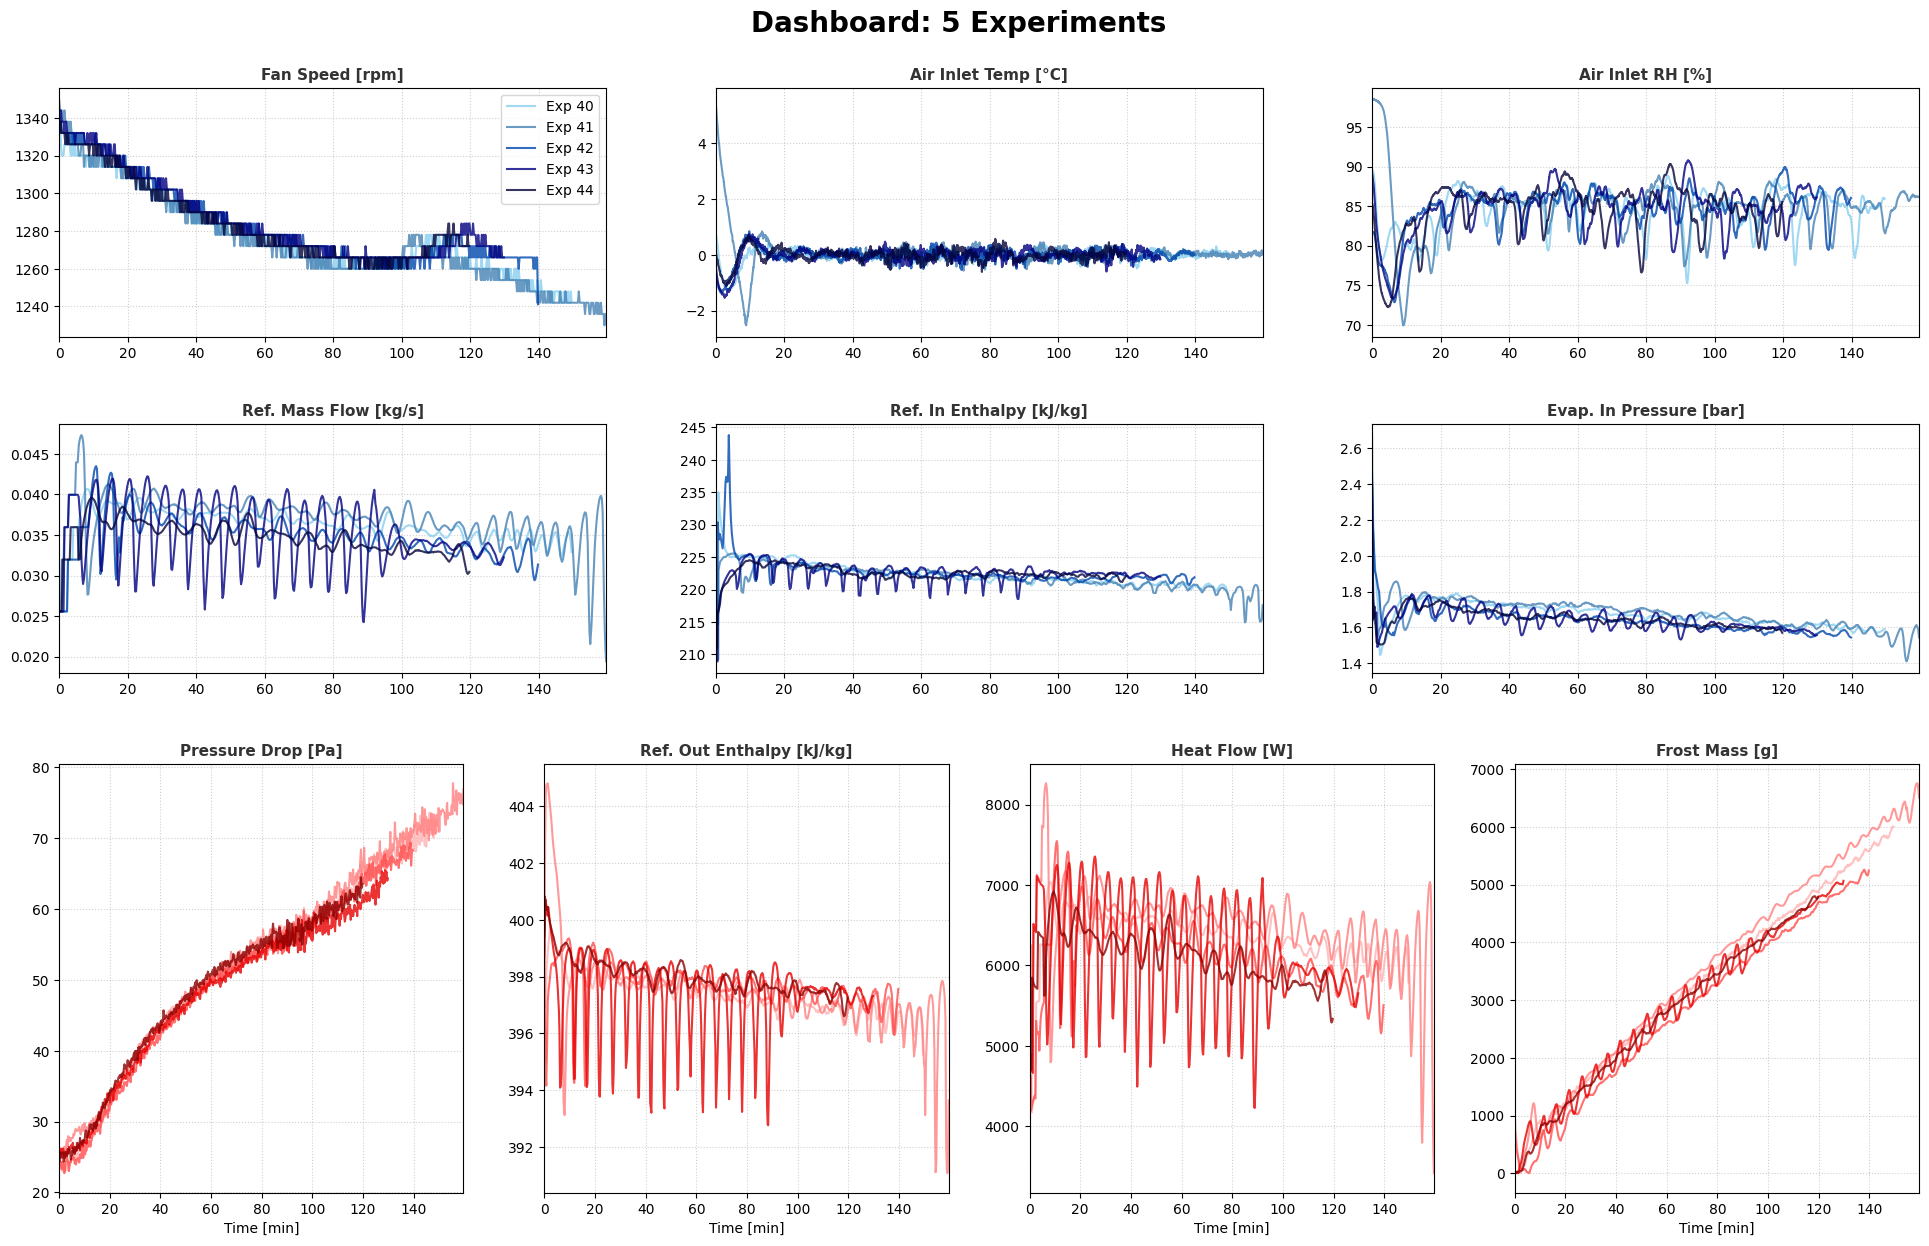

In [4]:
from pathlib import Path

experiment_ids = [40, 41, 42, 43, 44]
path_exp = Path(r"D:\mbc_nba\OptiAbt_Daten\Versuche\CSV_Export")


plot_experiments_simple(experiment_ids, path_exp, save_fig=False, group_name=None)

### Simulation

In [ ]:
from pathlib import Path
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost_model import FrostModel
from frost_evaporator.simulation_workflow import MultiExperimentAnalyzer, FrostEvaporatorSimulation, SimulationVisualizer

# --- MAIN ---

# 1. Define the group of experiments to combine (Label : List of IDs)
experiment_groups = {
    # "tets": [40],
    # "+3 °C":              [52, 53, 55, 56, 67],
    # "+0 °C (Version 1)":  [3, 4, 5, 7, 8],
    # "+0 °C (Version 2)":  [9, 10, 11, 16, 20],
    # "+0 °C (Version 3)":  [20, 22, 23, 25, 36],
    "+0 °C (Version 4)":  [40, 41, 42, 43, 44],
    # "+0 °C (Version 5)":  [45, 46, 47, 48, 49],
    # "-7 °C":              [27, 28, 29, 30],
    # "-12 °C":             [13, 18, 26]
}

cutoff_pct = 0.02
path_exp = Path(r"D:\mbc_nba\OptiAbt_Daten\Versuche\CSV_Export")


analyzer = MultiExperimentAnalyzer(project_root_rel='..')
sim = FrostEvaporatorSimulation("config_OptiAbt.yaml")
viz = SimulationVisualizer(sim.params)


# 2. Iterate through each group
for group_name, experiment_ids in experiment_groups.items():
    
    print(f"\n{'='*40}")
    print(f"Processing Group: {group_name}")
    print(f"IDs: {experiment_ids}")
    print(f"{'='*40}")

    try:
        # Run analysis
        exp_data = analyzer.analyze(
            exp_ids=experiment_ids, 
            data_path=path_exp, 
            cutoff_pct=cutoff_pct, 
            time_step=sim.params.time_step
        )



        # Run Simulation
        states_history, inputs_history = sim.run(exp_data)

        # Plot 
        viz.plot_comparison(states_history, inputs_history, experiment_ids, path_exp, cutoff_pct, group_name=group_name)
        viz.plot_detailed(states_history, inputs_history, experiment_ids)
        viz.plot_roughness(states_history, experiment_ids[0])
        viz.plot_frost_distribution(states_history)

        print(f"-> Success: Simulation complete for {group_name}.")

    except Exception as e:
        import traceback
        print(f"!!! CRITICAL FAILURE in Group {group_name} !!!")
        print(f"Error Message: {e}")
        traceback.print_exc()
        print("-> Skipping to next group...")

print(f"\nAll experiment groups processed.")

In [ ]:

# # combined_exp_inputs = analyze_combined_experiments(experiment_ids, path_exp, cutoff_pct)




# target_data = get_group_average_data(experiment_ids, path_exp, cutoff_pct)

# sim_res = {
#     'dp': np.array([sum(s.air.pressure_drop for s in step) for step in states_history]),
#     'Q': np.array([sum(s.hmt.Q_dot_total for s in step) * params.register_amount for step in states_history]),
#     'm_frost': np.array([sum(s.frost.mass for s in step) * 1000.0 * params.register_amount for step in states_history])
# }

# calculate_loss(sim_res, target_data)


<!-- ### Run Mutliple Simulations -->

### Optimization

In [9]:
# import optuna
# import numpy as np
# import pandas as pd
# import os
# from pathlib import Path

# # =========================================================================
# # 1. KONFIGURATION
# # =========================================================================
# OPTIMIZATION_SETS = {
#     "Group_Plus0":   [40, 41, 42, 43, 44],
#     "Group_Minus7":  [27, 28, 29, 30],
#     "Group_Minus12": [13, 18, 26]
# }
# CUTOFF_PCT = 0.02
# path_exp = Path(r"D:\mbc_nba\OptiAbt_Daten\Versuche\CSV_Export")
# PARAM_RANGE = [0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4]

# # =========================================================================
# # 2. ROBUSTE HILFSFUNKTIONEN
# # =========================================================================

# def to_numpy(data):
#     """Konvertiert Pandas Series/DataFrames sicher in Numpy, falls nötig."""
#     if hasattr(data, "values"):
#         return data.values
#     return np.array(data)

# def get_group_average_data(experiment_ids, path_exp, cutoff_pct):
#     """
#     Lädt Experimente und bildet Durchschnittswerte. 
#     Behandelt 'all zero' Spalten und Attribut-Fehler.
#     """
#     group_results = {'dp': [], 'Q': [], 'm_frost': []}
    
#     for exp_id in experiment_ids:
#         try:
#             f_data = path_exp / f"{exp_id}_data.csv"
#             f_kk = path_exp / f"{exp_id}_data_KK.csv"
            
#             if not f_data.exists() or not f_kk.exists():
#                 continue

#             df = pd.read_csv(f_data, sep=';', decimal='.', on_bad_lines='skip', low_memory=False)
#             df_kk = pd.read_csv(f_kk, sep=';', decimal='.', low_memory=False)

#             # Filterung (Modus 1 = Aktive Simulation)
#             col_modus = 'modus_val' if 'modus_val' in df.columns else 'modus'
#             if col_modus in df.columns:
#                 mask = df[col_modus] == 1
#                 df = df[mask]
#                 df_kk = df_kk.iloc[df.index] # Synchronisieren

#             if df.empty:
#                 continue

#             # --- EXTRAKTION MIT FEHLERHANDLING ---
#             # Druckverlust
#             dp = to_numpy(df['Delta_P_VD']) if 'Delta_P_VD' in df.columns else np.zeros(len(df))
            
#             # Wärmestrom Q = m_dot * (h_out - h_in)
#             m_ref = to_numpy(df['MSS_rMassenstrom']) / 1000.0
#             h_out = to_numpy(df['VD_h_out'])
#             h_in_col = 'VD_h_in_korr' if 'VD_h_in_korr' in df.columns else 'VD_isenthalp_h_in'
#             h_in = to_numpy(df[h_in_col])
#             Q = m_ref * (h_out - h_in) * 1000.0

#             # Frostmasse
#             col_mass = 'WAAGEN_Waage1_Masse_smooth' if 'WAAGEN_Waage1_Masse_smooth' in df.columns else 'WAAGEN_Waage2_Masse'
#             if col_mass in df.columns:
#                 m_raw = to_numpy(df[col_mass])
#                 m_frost = (m_raw - np.nanmin(m_raw)) * 1000.0
#             else:
#                 m_frost = np.zeros(len(df))

#             group_results['dp'].append(dp)
#             group_results['Q'].append(Q)
#             group_results['m_frost'].append(m_frost)

#         except Exception as e:
#             print(f"Fehler bei ID {exp_id}: {e}")

#     # Aggregation: Wir mitteln die Verläufe
#     final_avg = {}
#     for key, lists in group_results.items():
#         if lists:
#             # Da Zeitreihen unterschiedliche Längen haben können, 
#             # nehmen wir hier den Median der Endwerte oder interpolieren auf eine Standardlänge
#             # Vereinfachung für die Optimierung:
#             max_len = max(len(l) for l in lists)
#             padded_lists = [np.pad(l, (0, max_len - len(l)), 'edge') for l in lists]
#             final_avg[key] = np.mean(padded_lists, axis=0)
#         else:
#             final_avg[key] = None
            
#     return final_avg

# def calculate_loss(sim_res, target_data):
#     """Berechnet Fehler zwischen Simulation und gemitteltem Experiment."""
#     total_err = 0
#     valid_metrics = 0
    
#     for key in ['dp', 'Q', 'm_frost']:
#         if target_data[key] is not None:
#             # Interpolation der Simulation auf die Länge der Experimental-Daten
#             y_sim = sim_res[key]
#             y_exp = target_data[key]
            
#             if len(y_sim) != len(y_exp):
#                 y_sim = np.interp(np.linspace(0, 1, len(y_exp)), np.linspace(0, 1, len(y_sim)), y_sim)

#             # Cutoff anwenden
#             start = int(len(y_exp) * CUTOFF_PCT)
#             end = int(len(y_exp) * (1 - CUTOFF_PCT))
            
#             y_sim_c = y_sim[start:end]
#             y_exp_c = y_exp[start:end]
            
#             # RMSE oder MAPE (MAPE hier robuster für unterschiedliche Skalen)
#             denom = np.abs(np.mean(y_exp_c))
#             if denom < 1e-3: denom = 1.0 # Schutz gegen div/0
            
#             err = np.sqrt(np.mean((y_sim_c - y_exp_c)**2)) / denom
#             total_err += err
#             valid_metrics += 1
            
#     return total_err / valid_metrics if valid_metrics > 0 else 1e6

# # =========================================================================
# # 3. OPTUNA TRIAL
# # =========================================================================

# def objective(trial):
#     # Parameter vorschlagen
#     params.correction_factor_h_conv_air = trial.suggest_categorical("h_conv", PARAM_RANGE)
#     params.correction_factor_surface_density = trial.suggest_categorical("surf_dens", PARAM_RANGE)
#     params.correction_factor_betta_air = trial.suggest_categorical("betta", PARAM_RANGE)
#     params.correction_factor_k_frost = trial.suggest_categorical("k_frost", PARAM_RANGE)

#     group_losses = []
    
#     for group_name, ids in OPTIMIZATION_SETS.items():
#         # 1. Aggregierte Eingangsdaten für die Simulation
#         combined_inputs = analyze_combined_experiments(ids, path_exp, CUTOFF_PCT, time_step=params.time_step)
        
#         # 2. Simulation
#         states, inputs = run_simulation_case(combined_inputs, params)
        
#         # 3. Sim-Ergebnisse extrahieren
#         sim_res = {
#             'dp': np.array([sum(s.air.pressure_drop for s in step) for step in states]),
#             'Q': np.array([sum(s.hmt.Q_dot_total for s in step) * params.register_amount for step in states]),
#             'm_frost': np.array([sum(s.frost.mass for s in step) * 1000.0 * params.register_amount for step in states])
#         }
        
#         # 4. Vergleichsdaten laden
#         target_data = get_group_average_data(ids, path_exp, CUTOFF_PCT)
        
#         # 5. Loss berechnen
#         group_losses.append(calculate_loss(sim_res, target_data))
        
#     return np.sum(group_losses)

# # =========================================================================
# # 4. START
# # =========================================================================
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=500)

# print("Beste Parameter:", study.best_params)